 ## Step 1: Load and Explore the Dataset

In [1]:
#import required library
import pandas as pd

In [2]:
# Load the Dataset
df = pd.read_csv("HR-Employee-Attrition.csv")

In [3]:
# Preview the Data View the first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Summary of the dataset
df.info()

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# Shape of the dataset
print("Dataset contains:", df.shape[0], "rows and", df.shape[1], "columns")

# List of columns
print("\nColumns:\n", df.columns.tolist())

Dataset contains: 1470 rows and 35 columns

Columns:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
# For quick understanding of categorical spread
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married  

## Step 2: EDA – Explore Employee Attrition

In [7]:
# import required Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate:
 Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


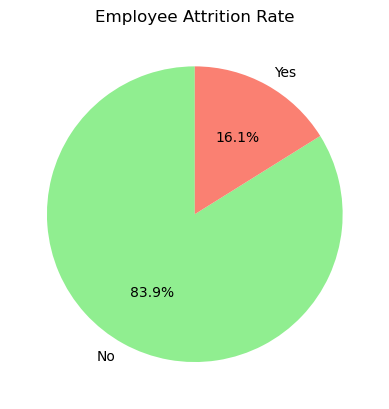

In [8]:
# Count of attrition
print(df['Attrition'].value_counts())
print("\nAttrition Rate:\n", df['Attrition'].value_counts(normalize=True) * 100)

# Pie Chart
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=90)
plt.title("Employee Attrition Rate")
plt.ylabel("")
plt.show()

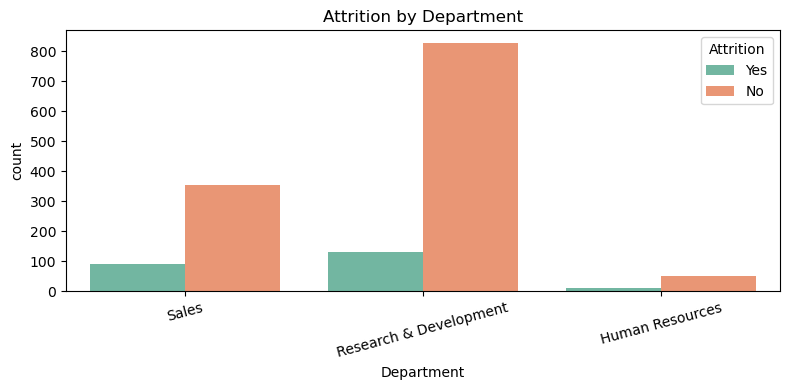

In [9]:
# Attrition by Department
plt.figure(figsize=(8, 4))
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2')
plt.title('Attrition by Department')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

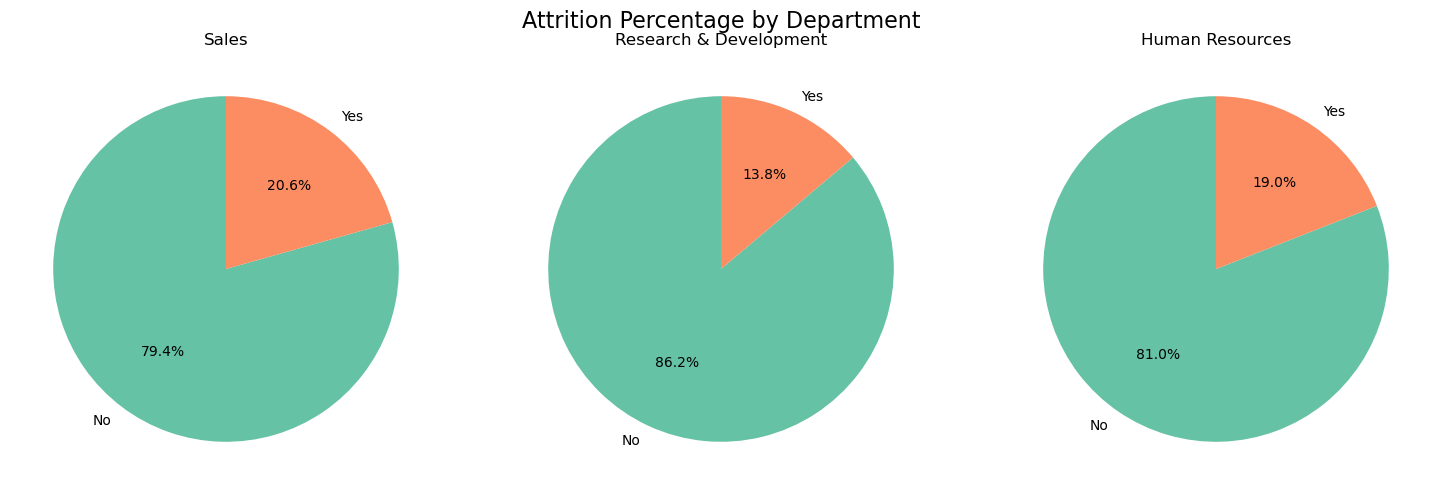

In [10]:
# Pie chart with percent by department
# Get unique departments
departments = df['Department'].unique()

# Create subplots
fig, axes = plt.subplots(1, len(departments), figsize=(15, 5))

for i, dept in enumerate(departments):
    # Filter data for current department
    data = df[df['Department'] == dept]['Attrition'].value_counts(normalize=True)
    
    # Plot pie chart
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
    axes[i].set_title(dept)

plt.suptitle('Attrition Percentage by Department', fontsize=16)
plt.tight_layout()
plt.show()

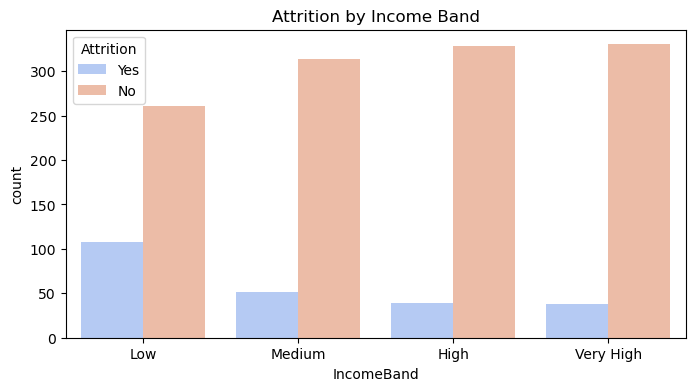

In [11]:
# Attrition by Monthly Income (Salary Band)
# Create income bands
df['IncomeBand'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(8, 4))
sns.countplot(x='IncomeBand', hue='Attrition', data=df, palette='coolwarm')
plt.title('Attrition by Income Band')
plt.show()

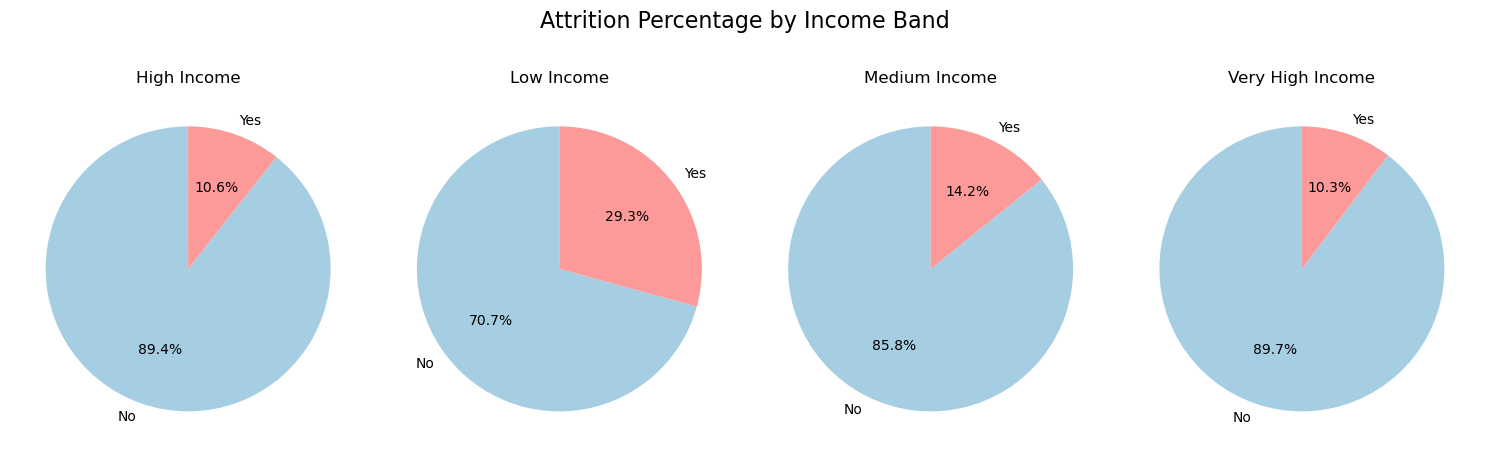

In [12]:
# Get unique income bands
income_bands = df['IncomeBand'].unique()

# Create subplots
fig, axes = plt.subplots(1, len(income_bands), figsize=(15, 5))

for i, band in enumerate(income_bands):
    # Filter data for current income band
    data = df[df['IncomeBand'] == band]['Attrition'].value_counts(normalize=True)
    
    # Plot pie chart
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', colors=['#a6cee3', '#fb9a99'], startangle=90)
    axes[i].set_title(f'{band} Income')

plt.suptitle('Attrition Percentage by Income Band', fontsize=16)
plt.tight_layout()
plt.show()

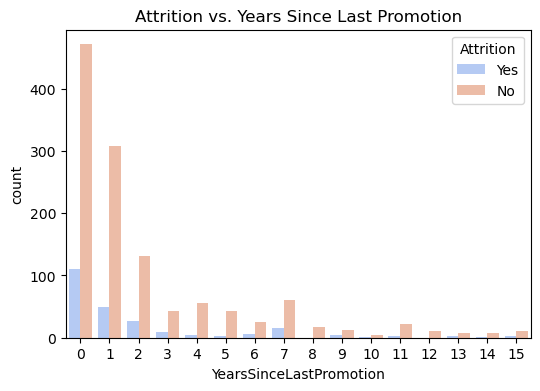

In [13]:
# Attrition vs Promotions
plt.figure(figsize=(6, 4))
sns.countplot(x='YearsSinceLastPromotion', hue='Attrition', data=df, palette='coolwarm')
plt.title('Attrition vs. Years Since Last Promotion')
plt.show()

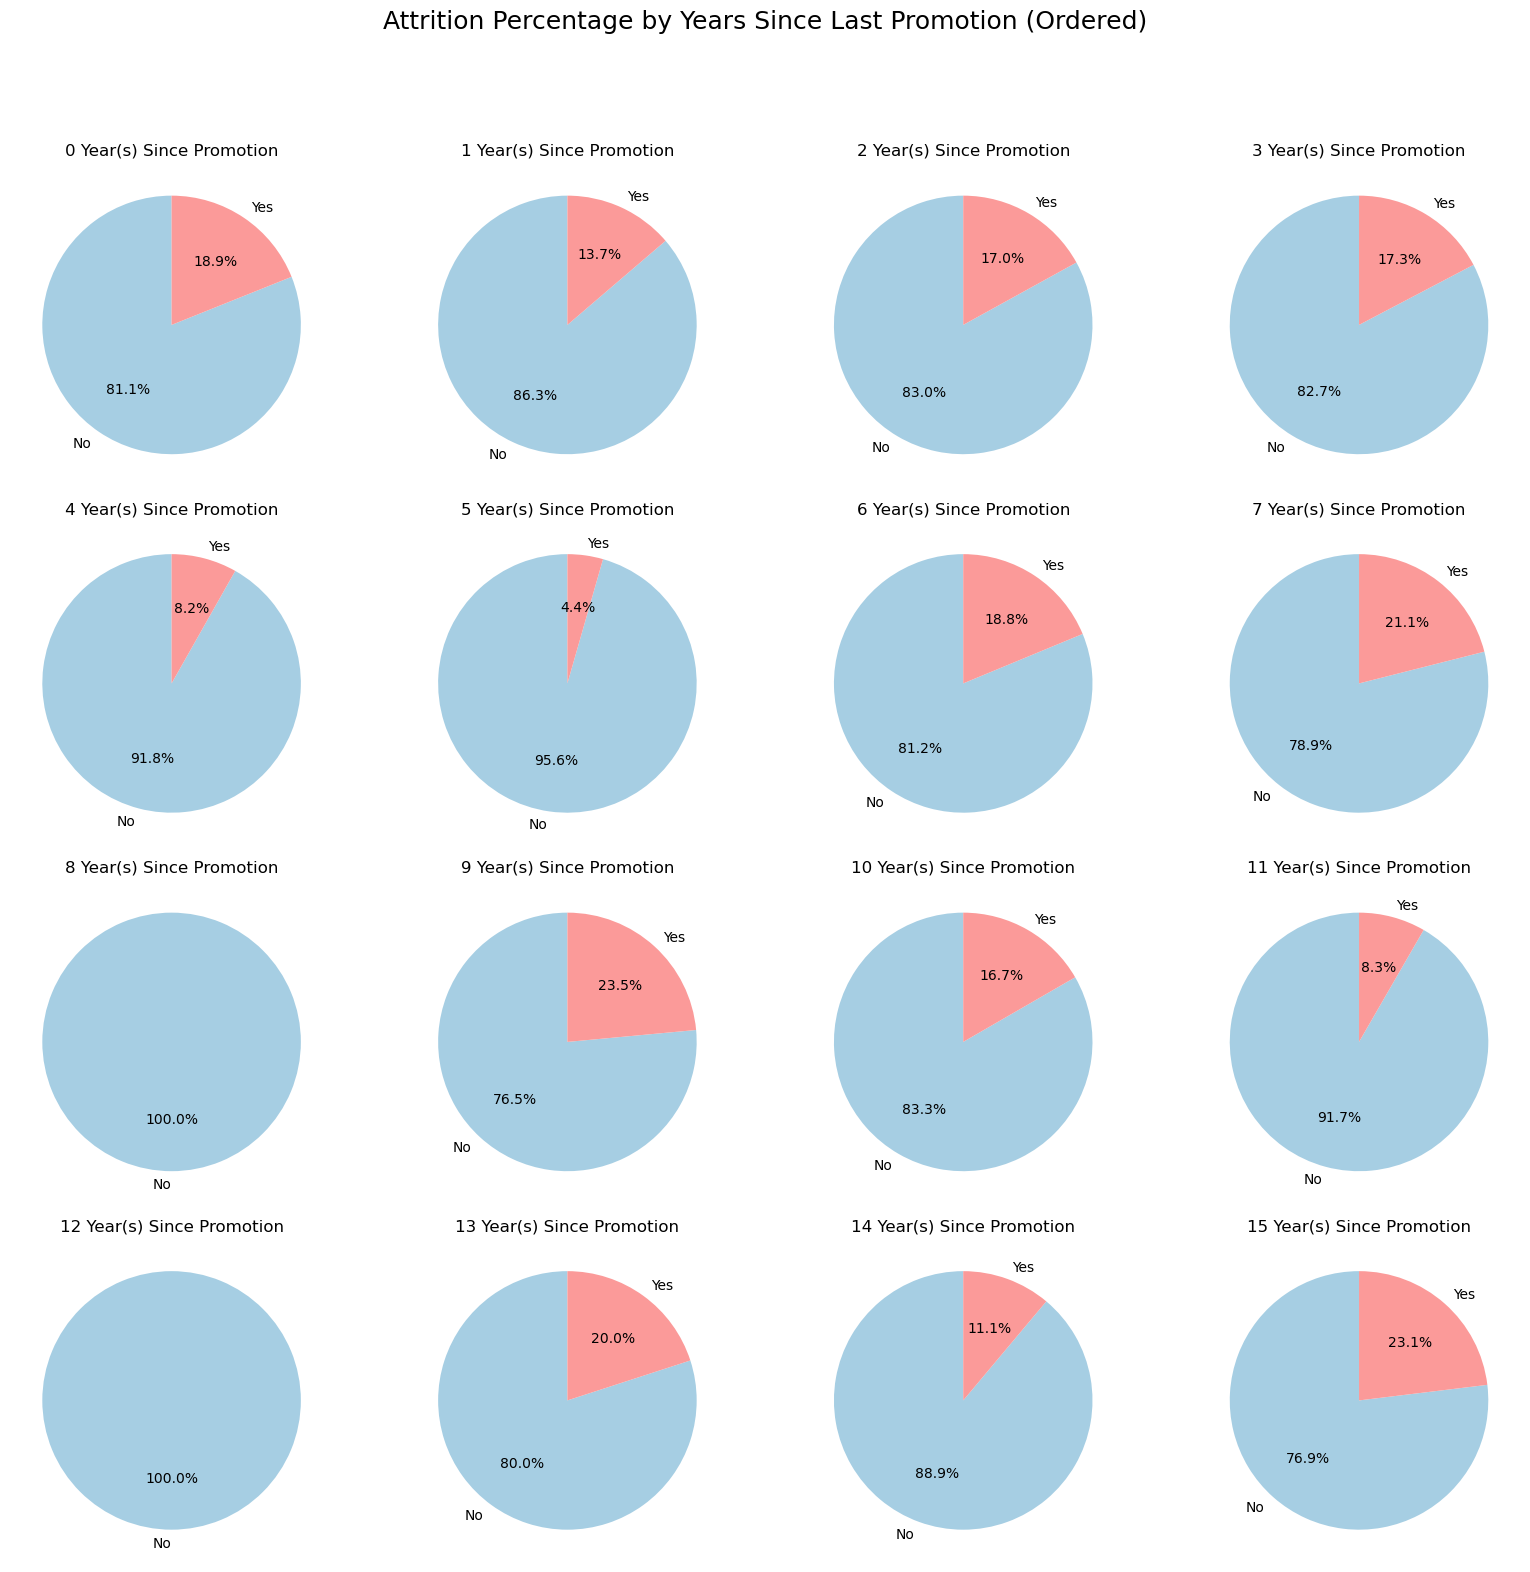

In [14]:
import math
# Sort the unique years
YearsSince_LastPromotion = sorted(df['YearsSinceLastPromotion'].unique())

# Grid setup
cols = 4
rows = math.ceil(len(YearsSince_LastPromotion) / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

# Plot pie charts in sorted order
for i, year in enumerate(YearsSince_LastPromotion):
    data = df[df['YearsSinceLastPromotion'] == year]['Attrition'].value_counts(normalize=True)
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', colors=['#a6cee3', '#fb9a99'], startangle=90)
    axes[i].set_title(f'{year} Year(s) Since Promotion')

plt.suptitle('Attrition Percentage by Years Since Last Promotion (Ordered)', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

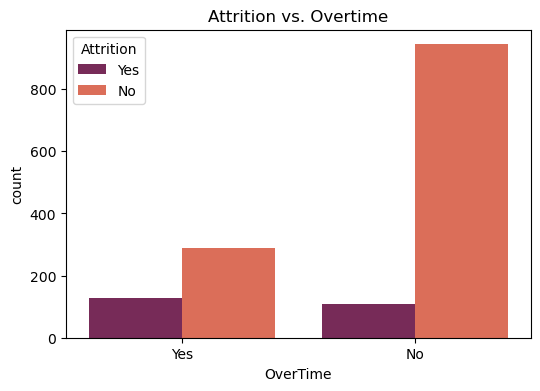

In [15]:
# Attrition vs Overtime
plt.figure(figsize=(6, 4))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='rocket')
plt.title('Attrition vs. Overtime')
plt.show()

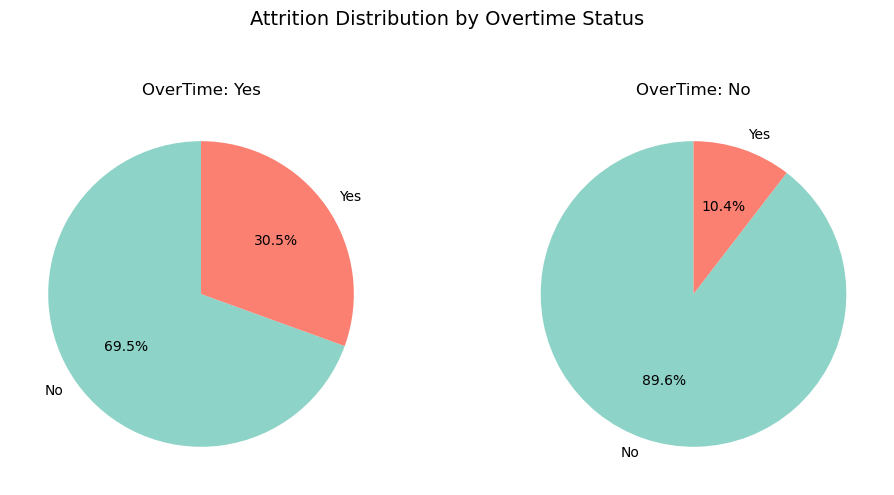

In [16]:



# Unique values in 'OverTime'
overtime_values = df['OverTime'].unique()

# Set up subplots
fig, axes = plt.subplots(1, len(overtime_values), figsize=(10, 5))

# Plot each pie chart
for i, value in enumerate(overtime_values):
    data = df[df['OverTime'] == value]['Attrition'].value_counts(normalize=True)
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', colors=['#8dd3c7', '#fb8072'], startangle=90)
    axes[i].set_title(f'OverTime: {value}')

# Add a common title with spacing
plt.suptitle('Attrition Distribution by Overtime Status', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9])  # top=0.9 leaves room for title
plt.show()

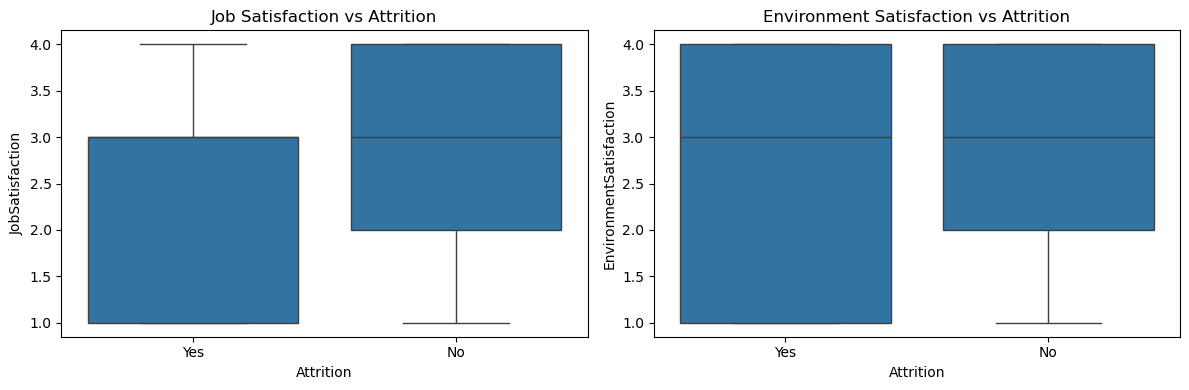

In [17]:
#Job Satisfaction & Environment Satisfaction
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df, ax=ax[0])
sns.boxplot(x='Attrition', y='EnvironmentSatisfaction', data=df, ax=ax[1])
ax[0].set_title('Job Satisfaction vs Attrition')
ax[1].set_title('Environment Satisfaction vs Attrition')
plt.tight_layout()
plt.show()

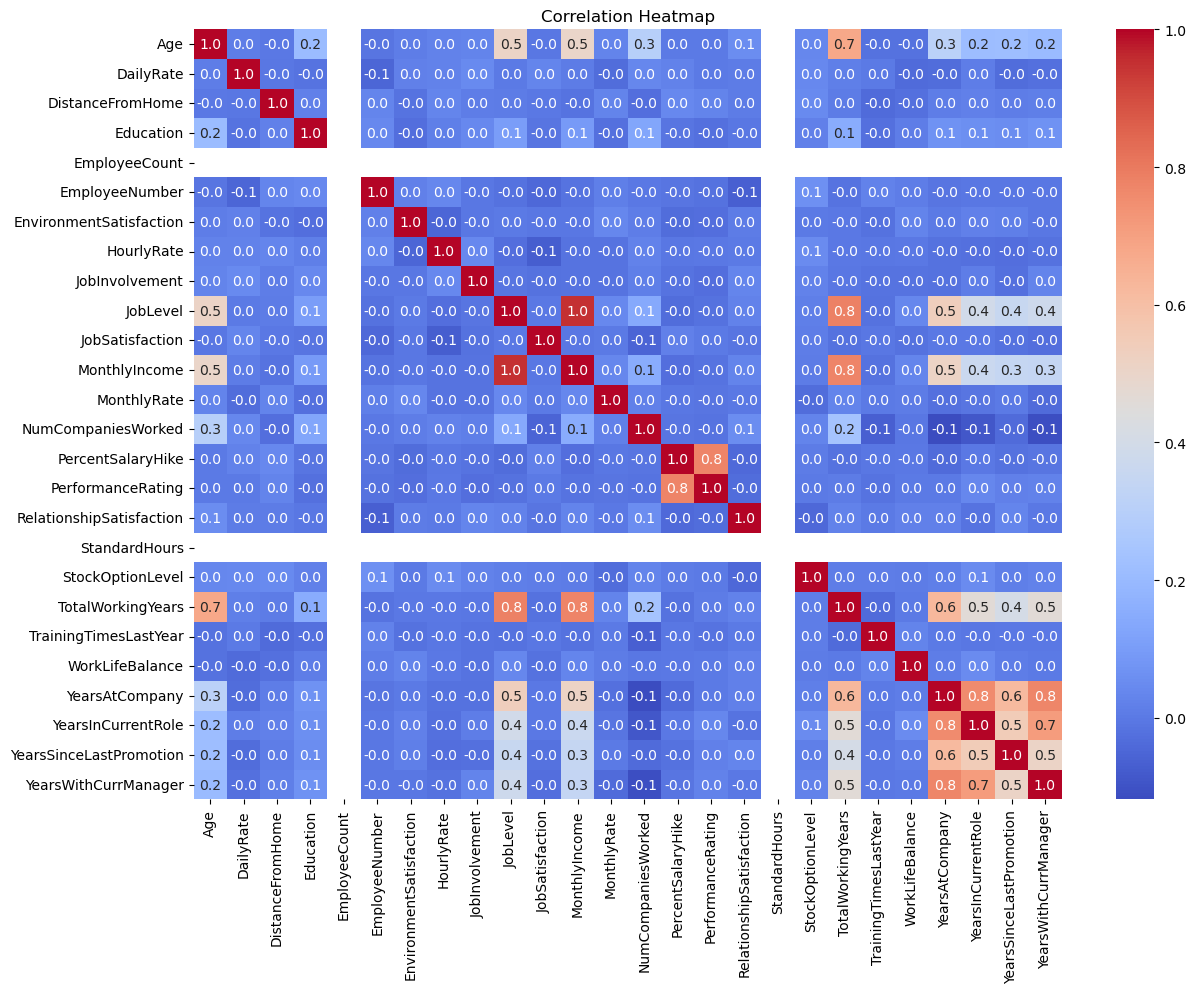

In [18]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Step 3: Feature Engineering

In [19]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_fe = df.copy()

# Label Encode binary columns
le = LabelEncoder()
df_fe['Attrition'] = le.fit_transform(df_fe['Attrition'])  # Yes=1, No=0
df_fe['OverTime'] = le.fit_transform(df_fe['OverTime'])    # Yes=1, No=0

# One-hot encode multi-category columns
df_fe = pd.get_dummies(df_fe, columns=[
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus'
], drop_first=True)

df_fe.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,1,4,4,92,2,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,7,1,40,3,...,False,True,False,False,False,False,False,False,True,False


In [20]:
# Scale Numeric Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select numeric columns to scale
numeric_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany', 
                'YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion']

df_fe[numeric_cols] = scaler.fit_transform(df_fe[numeric_cols])

In [21]:
df_fe.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,1,1102,-1.010909,2,1,1,2,94,3,...,False,False,False,False,False,False,True,False,False,True
1,1.322365,0,279,-0.147150,1,1,2,3,61,2,...,False,False,False,False,False,True,False,False,True,False
2,0.008343,1,1373,-0.887515,2,1,4,4,92,2,...,False,True,False,False,False,False,False,False,False,True
3,-0.429664,0,1392,-0.764121,4,1,5,4,56,3,...,False,False,False,False,False,True,False,False,True,False
4,-1.086676,0,591,-0.887515,1,1,7,1,40,3,...,False,True,False,False,False,False,False,False,True,False


In [22]:
# Create New Features
# 1. Tenure Buckets
def tenure_bucket(years):
    if years <= 2:
        return '0-2'
    elif years <= 5:
        return '2-5'
    elif years <= 10:
        return '5-10'
    else:
        return '10+'

df_fe['TenureBucket'] = df['YearsAtCompany'].apply(tenure_bucket)
df_fe = pd.get_dummies(df_fe, columns=['TenureBucket'], drop_first=True)

In [23]:
# 2. Satisfaction Level (Job Satisfaction)
def satisfaction_level(score):
    if score <= 2:
        return 'Low'
    elif score == 3:
        return 'Medium'
    else:
        return 'High'

df_fe['SatisfactionLevel'] = df['JobSatisfaction'].apply(satisfaction_level)
df_fe = pd.get_dummies(df_fe, columns=['SatisfactionLevel'], drop_first=True)

In [24]:
# 3. Workload Index
df_fe['WorkloadIndex'] = df['NumCompaniesWorked'] + df['TotalWorkingYears'] - df['YearsAtCompany']

In [25]:
print("Final shape of dataset after feature engineering:", df_fe.shape)
df_fe.head()

Final shape of dataset after feature engineering: (1470, 56)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,TenureBucket_10+,TenureBucket_2-5,TenureBucket_5-10,SatisfactionLevel_Low,SatisfactionLevel_Medium,WorkloadIndex
0,0.446350,1,1102,-1.010909,2,1,1,2,94,3,...,True,False,False,True,False,False,True,False,False,10
1,1.322365,0,279,-0.147150,1,1,2,3,61,2,...,False,False,True,False,False,False,True,True,False,1
2,0.008343,1,1373,-0.887515,2,1,4,4,92,2,...,False,False,False,True,False,False,False,False,True,13
3,-0.429664,0,1392,-0.764121,4,1,5,4,56,3,...,False,False,True,False,False,False,True,False,True,1
4,-1.086676,0,591,-0.887515,1,1,7,1,40,3,...,False,False,True,False,False,False,False,True,False,13


## Step 4: Clustering with KMeans

In [26]:
#  Select Features for Clustering
# Optional: drop the target 'Attrition' for clustering
features_for_cluster = df_fe.drop(columns=['Attrition'])

# Double-check: remove any non-numeric columns
features_for_cluster = features_for_cluster.select_dtypes(include='number')

In [27]:
features_for_cluster.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,WorkloadIndex
0,0.446350,1102,-1.010909,2,1,1,2,94,3,2,...,80,0,8,0,1,-0.164613,-0.063296,-0.679146,0.245834,10
1,1.322365,279,-0.147150,1,1,2,3,61,2,2,...,80,1,10,3,3,0.488508,0.764998,-0.368715,0.806541,1
2,0.008343,1373,-0.887515,2,1,4,4,92,2,1,...,80,0,7,3,3,-1.144294,-1.167687,-0.679146,-1.155935,13
3,-0.429664,1392,-0.764121,4,1,5,4,56,3,1,...,80,0,8,3,3,0.161947,0.764998,0.252146,-1.155935,1
4,-1.086676,591,-0.887515,1,1,7,1,40,3,1,...,80,1,6,3,3,-0.817734,-0.615492,-0.058285,-0.595227,13


In [28]:
# Normalize the Data (if not already)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_for_cluster)

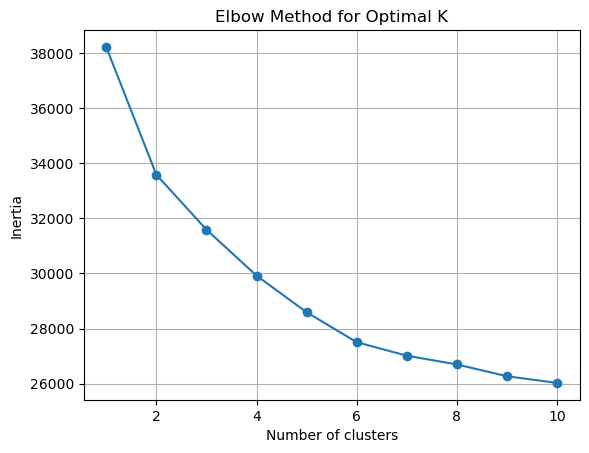

In [29]:
# Use the Elbow Method to Find Optimal K
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [30]:
# Apply KMeans
# Choose K (e.g., 4 based on elbow curve)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
df_fe['Cluster'] = clusters


In [31]:
#  Analyze the Clusters
# See average profile of each cluster
cluster_summary = df_fe.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

# Check Attrition rate per cluster
print("\nAttrition Rate by Cluster:")
print(df_fe.groupby('Cluster')['Attrition'].mean())

              Age  Attrition   DailyRate  DistanceFromHome  Education  \
Cluster                                                                 
0        1.304845   0.080000  848.273333         -0.020465   3.153333   
1       -0.233745   0.200000  800.524324          0.075627   2.794595   
2       -0.358651   0.189356  803.982673         -0.019785   2.839109   
3        0.419896   0.107034  778.892966          0.015489   3.051988   

         EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  HourlyRate  \
Cluster                                                                       
0                  1.0      919.913333                 2.720000   67.086667   
1                  1.0      964.762162                 2.648649   65.605405   
2                  1.0     1080.248762                 2.727723   65.782178   
3                  1.0      970.162080                 2.749235   65.773700   

         JobInvolvement  ...  JobRole_Sales Executive  \
Cluster                  ... 

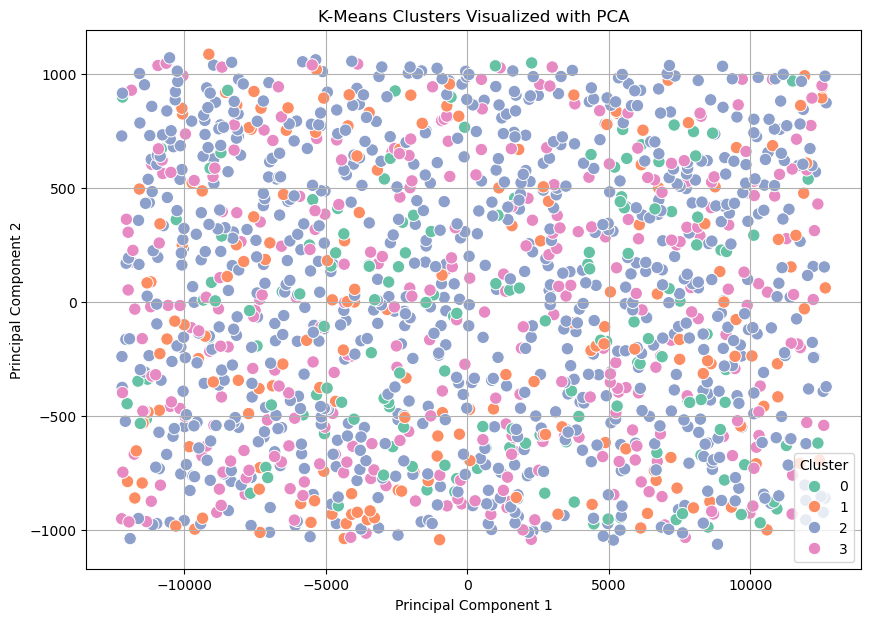

In [32]:
# Visualize Clusters with PCA
from sklearn.decomposition import PCA

# Keep only numeric features
features_for_pca = df_fe.drop(columns=['Attrition']).select_dtypes(include=['number'])

# Apply PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(features_for_pca)

# DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df_fe['Cluster']

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=80)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

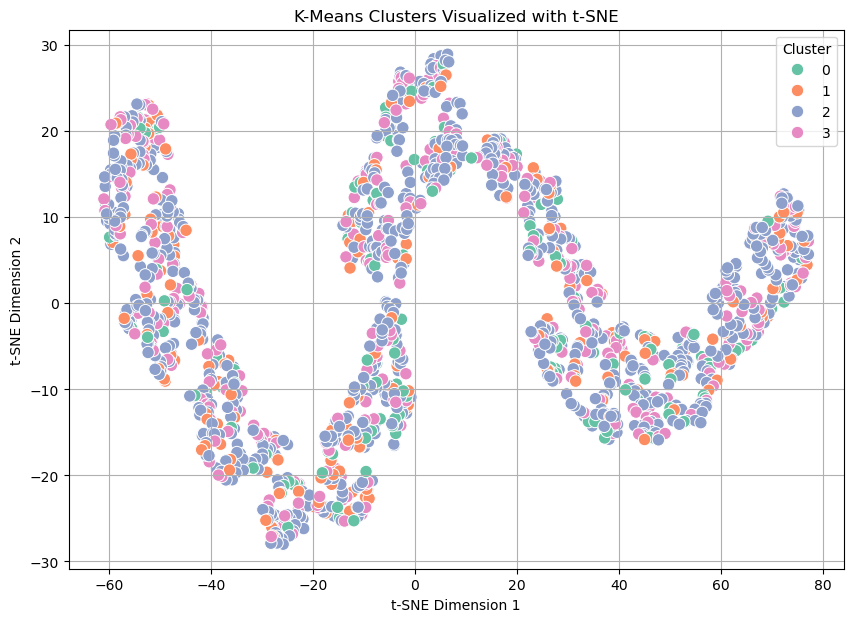

In [33]:
#  t-SNE Code for Cluster Visualization
from sklearn.manifold import TSNE

# Only numeric features
features_for_tsne = df_fe.drop(columns=['Attrition']).select_dtypes(include=['number'])

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_components = tsne.fit_transform(features_for_tsne)

# Create DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_components, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = df_fe['Cluster']

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='Set2', s=80)
plt.title('K-Means Clusters Visualized with t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## Step 5: Model Building for Attrition Prediction

In [34]:

# Encode and prepare features
X = pd.get_dummies(df_fe.drop('Attrition', axis=1), drop_first=True)
X = X.astype(int)
y = df_fe['Attrition']

# Now split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       247
           1       0.64      0.38      0.48        47

    accuracy                           0.87       294
   macro avg       0.77      0.67      0.70       294
weighted avg       0.85      0.87      0.85       294

Confusion Matrix:
 [[237  10]
 [ 29  18]]
Accuracy: 0.8673469387755102


/home/raza/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


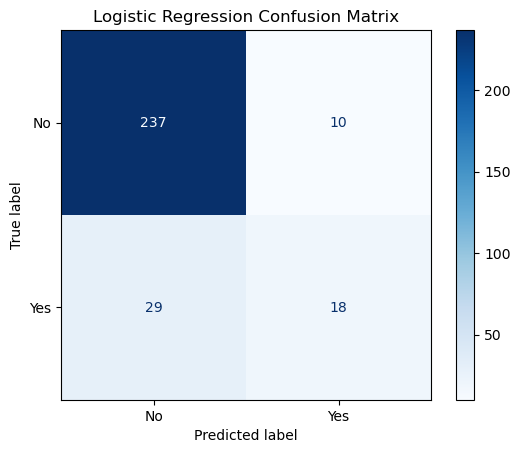

In [42]:
# Logistic Regression (Baseline Model)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predict
y_pred_logreg = logreg.predict(X_test)

# Evaluate
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, display_labels=['No', 'Yes'], cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("logreg_confusion_matrix.png")


Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       247
           1       0.36      0.19      0.25        47

    accuracy                           0.82       294
   macro avg       0.61      0.56      0.57       294
weighted avg       0.78      0.82      0.79       294

Confusion Matrix:
 [[231  16]
 [ 38   9]]
Accuracy: 0.8163265306122449


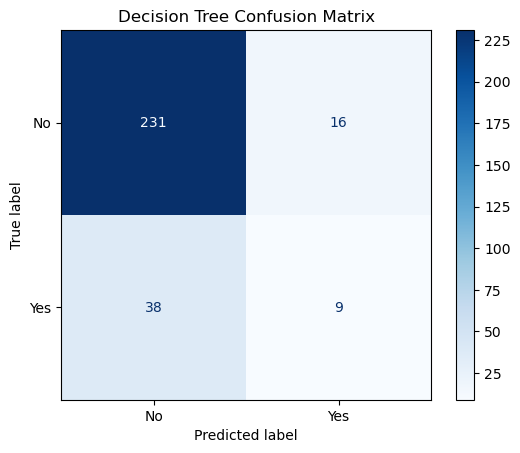

In [43]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Model
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

# Predict
y_pred_dtree = dtree.predict(X_test)

# Evaluate
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dtree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dtree))
print("Accuracy:", accuracy_score(y_test, y_pred_dtree))

ConfusionMatrixDisplay.from_estimator(dtree, X_test, y_test, display_labels=['No', 'Yes'], cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.savefig("DecisionTree_matrix.png")

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

Confusion Matrix:
 [[244   3]
 [ 43   4]]
Accuracy: 0.8435374149659864


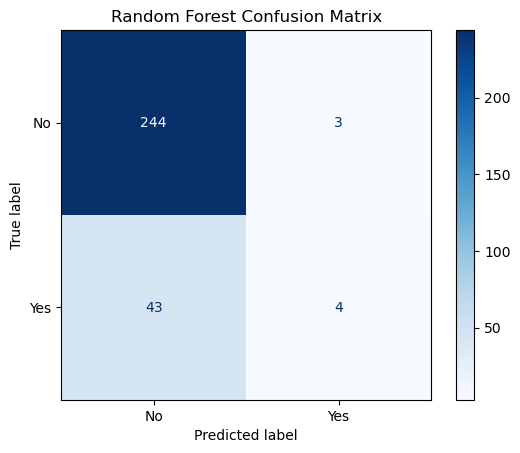

In [44]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Model
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# Predict
y_pred_rfc = rfc.predict(X_test)

# Evaluate
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rfc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rfc))
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))

ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test, display_labels=['No', 'Yes'], cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.savefig("RandomForest_matrix.png")

In [45]:

# Comparing Model Performance

# Create a dictionary to store performance metrics
model_metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_dtree),
        accuracy_score(y_test, y_pred_rfc)
    ],
    'Precision': [
        classification_report(y_test, y_pred_logreg, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_dtree, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, y_pred_rfc, output_dict=True)['weighted avg']['precision']
    ],
    'Recall': [
        classification_report(y_test, y_pred_logreg, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_dtree, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, y_pred_rfc, output_dict=True)['weighted avg']['recall']
    ],
    'F1 Score': [
        classification_report(y_test, y_pred_logreg, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_dtree, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test, y_pred_rfc, output_dict=True)['weighted avg']['f1-score']
    ]
}

# Convert to DataFrame for easy comparison
model_comparison = pd.DataFrame(model_metrics)

# Display the comparison table
print(model_comparison)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.867347   0.851312  0.867347  0.853001
1        Decision Tree  0.816327   0.779006  0.816327  0.792181
2        Random Forest  0.843537   0.805613  0.843537  0.791448


## Step 6: Model Explainability with SHAP

In [46]:
import shap

# Initialize SHAP explainer for Logistic Regression
explainer = shap.Explainer(logreg, X_train)

# Compute SHAP values for the test set
shap_values = explainer(X_test)
print(X_test.columns)
print(shap_values)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing D

/home/raza/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


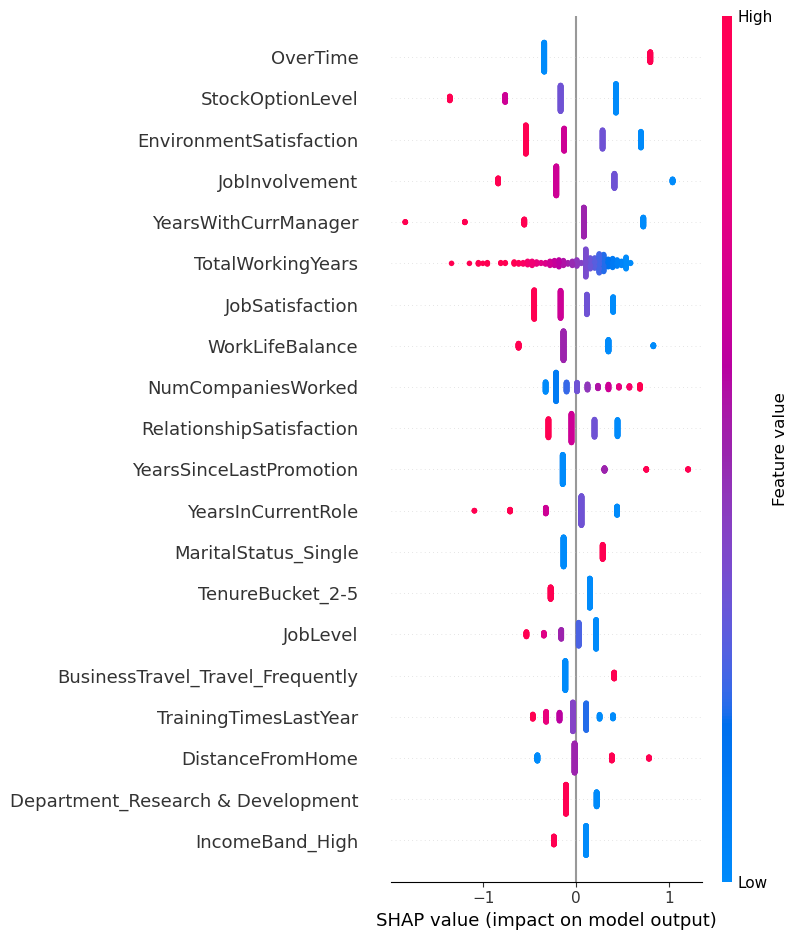

In [57]:
explainer = shap.Explainer(logreg, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_summary.png')


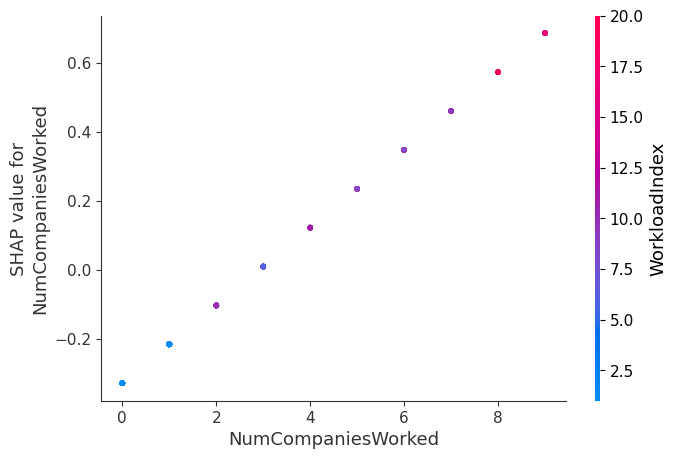

In [48]:
# Use the correct feature names
shap.dependence_plot('NumCompaniesWorked', shap_values.values, X_test)

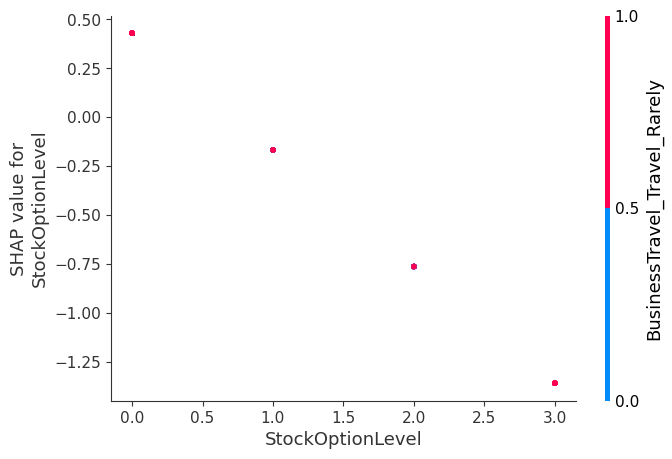

In [49]:
shap.dependence_plot('StockOptionLevel', shap_values.values, X_test)

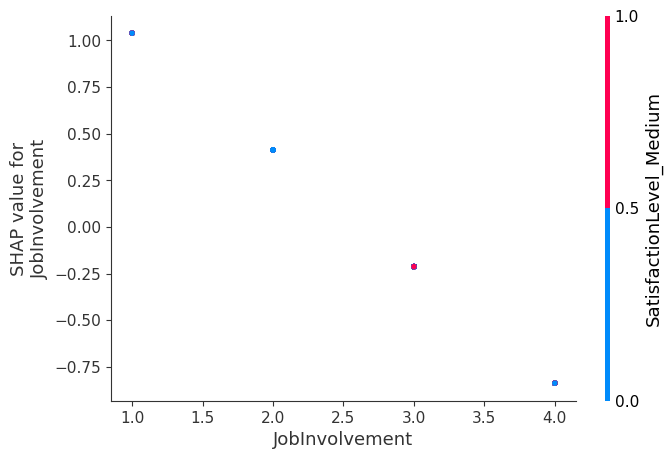

In [50]:
shap.dependence_plot('JobInvolvement', shap_values.values, X_test)

In [51]:
import numpy as np

# Assuming you already have:
# shap_values: SHAP Explanation object (e.g., from shap.Explainer(X))
# X: Feature matrix (pandas DataFrame)

# Extract SHAP values as a NumPy array
shap_vals_array = shap_values.values  # shape: (num_samples, num_features)

# Calculate mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_vals_array).mean(axis=0)

# Calculate mean SHAP value (can be positive or negative)
mean_signed_shap = shap_vals_array.mean(axis=0)

# Create DataFrame with feature names
shap_importance_df = pd.DataFrame({
    'Feature': shap_values.feature_names,  # or X.columns if they match
    'SHAP Importance': mean_abs_shap,
    'Mean SHAP Value': mean_signed_shap
})

# Add interpretation column (based on sign of mean SHAP value)
shap_importance_df['Attrition Impact'] = shap_importance_df['Mean SHAP Value'].apply(
    lambda x: 'Increases Attrition' if x > 0 else 'Decreases Attrition'
)

# Sort by SHAP Importance
shap_importance_df = shap_importance_df.sort_values(by='SHAP Importance', ascending=False)

# Save to CSV
shap_importance_df.to_csv('shap_feature_importance_with_attrition.csv', index=False)


In [52]:
# Extract SHAP values as a DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=shap_values.feature_names)

# Add a prefix to distinguish SHAP columns
shap_df = shap_df.add_prefix("SHAP_")

# Concatenate original data with SHAP values
df_with_shap = pd.concat([df.reset_index(drop=True), shap_df.reset_index(drop=True)], axis=1)

# Save to CSV (optional)
df_with_shap.to_csv("HR_Attrition_with_SHAP.csv", index=False)
